# 🎯 07 — Calibración de Modelos y Exportación para Dashboard
## Silver · Turbina Kelmarsh T1 · 2018–2022

---

### Por qué calibrar

Los modelos de regresión entrenados predicen `hours_to_fault`, pero los scatter plots
muestran un problema sistemático: **el modelo comprime las predicciones hacia la zona central**.
Cuando el fallo real está a 5h, predice ~45h. Cuando está a 115h, también predice ~60h.

Esto ocurre porque LightGBM con pocos árboles (5-38 en nuestro caso) aprende la media
del target en cada hoja pero no aprende bien los extremos. El modelo sabe que hay
degradación pero no sabe cuánto tiempo exacto queda.

### Solución: Isotonic Regression como calibrador de salida

La calibración isotónica (`IsotonicRegression`) aprende la función monótona que mapea
las predicciones brutas del regresor a predicciones corregidas, usando un conjunto
de validación separado. Es no paramétrica — no asume ninguna forma funcional.

El pipeline final es:
```
sensores → features rolling → LGBMRegressor → IsotonicRegression → horas_calibradas
```

### Split train / validación / test

Para calibrar correctamente necesitamos tres conjuntos separados:

| Conjunto | % del tiempo | Uso |
|----------|-------------|-----|
| Train | 0–70% | Entrenar LGBMRegressor (2018-01 → ~2022-02) |
| Validación | 70–80% | Entrenar IsotonicRegression (calibración) |
| Test | 80–100% | Evaluar el pipeline completo calibrado |

> El test es el mismo período que en el 06 — las métricas finales son comparables.

## 1. Imports y Configuración

In [1]:
import os, json, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

base_dir   = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')
models_dir = os.path.join(base_dir, 'data', 'models')
html_dir = os.path.join(base_dir, 'html')
images_dir = os.path.join(base_dir, 'docs','images')
os.makedirs(models_dir, exist_ok=True)

FAMILIES = {
    'yaw_cable':   {'lead_hours': 72,  'alert_h': 48,  'color': '#378ADD', 'label': 'Yaw / Cable'},
    'generator':   {'lead_hours': 120, 'alert_h': 72,  'color': '#D85A30', 'label': 'Generador'},
    'brake_hydro': {'lead_hours': 120, 'alert_h': 72,  'color': '#BA7517', 'label': 'Freno / Hidráulico'},
    'pitch_bat':   {'lead_hours': 336, 'alert_h': 168, 'color': '#1D9E75', 'label': 'Pitch / Baterías'},
}

LGBM_PARAMS_BASE = {
    'n_estimators': 1000, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1,
}
LGBM_PARAMS = {
    'yaw_cable':   {**LGBM_PARAMS_BASE, 'num_leaves': 63,  'min_child_samples': 20},
    'generator':   {**LGBM_PARAMS_BASE, 'num_leaves': 63,  'min_child_samples': 20},
    'brake_hydro': {**LGBM_PARAMS_BASE, 'num_leaves': 31,  'min_child_samples': 30},
    'pitch_bat':   {**LGBM_PARAMS_BASE, 'num_leaves': 63,  'min_child_samples': 20},
}

TRAIN_RATIO = 0.60   # 70% train, 10% validación, 20% test
VAL_RATIO   = 0.80   # corte validación/test (mismo que antes para test comparable)
print('✅ Configuración cargada')


✅ Configuración cargada


---

## 2. Función de Evaluación por Evento

Misma función que en el 06 — detecta si cada fallo real recibió
al menos una alerta antes de ocurrir.

In [2]:
def evaluate_by_event(test_df, y_pred_h, family, alert_h, lead_hours):
    df_e = test_df[['timestamp', f'is_pre_{family}']].copy()
    df_e['pred_h'] = y_pred_h
    df_e = df_e.sort_values('timestamp').reset_index(drop=True)
    is_pre = df_e[f'is_pre_{family}'].astype(bool)
    fault_starts = df_e['timestamp'][
        is_pre & ~is_pre.shift(1, fill_value=False)
    ].tolist()
    detected, details = 0, []
    for fs in fault_starts:
        mask     = (df_e['timestamp'] >= fs) & \
                   (df_e['timestamp'] < fs + pd.Timedelta(hours=lead_hours))
        min_pred = float(df_e.loc[mask, 'pred_h'].min()) if mask.any() else float(lead_hours)
        hit      = bool(min_pred <= alert_h)
        if hit: detected += 1
        details.append({'fault_start': fs, 'min_pred_h': round(min_pred,1), 'detected': hit})
    total = len(fault_starts)
    return {
        'event_recall':    round(detected/total, 4) if total > 0 else 0.0,
        'events_detected': detected, 'events_total': total, 'details': details,
    }

print('✅ Función definida')


✅ Función definida


---

## 3. Entrenamiento con Calibración por Familia

Para cada familia:
1. Entrena `LGBMRegressor` sobre el conjunto de train (0–70%)
2. Predice sobre el conjunto de validación (70–80%)
3. Entrena `IsotonicRegression` sobre esas predicciones — aprende a corregir el sesgo
4. Evalúa el pipeline completo sobre test (80–100%)
5. Guarda el modelo base + calibrador como pipeline

In [3]:
all_results = {}

for family, cfg in FAMILIES.items():
    t0 = time.time()
    print(f'\n{"="*60}')
    print(f'  {family.upper()}  —  calibración isotónica')
    print(f'{"="*60}')

    df = pd.read_parquet(os.path.join(silver_dir, f'features_{family}.parquet'))
    df = df.sort_values('timestamp').reset_index(drop=True)

    target_col = f'is_pre_{family}'
    hours_col  = f'hours_to_{family}'
    feat_cols  = [c for c in df.columns if c not in ['timestamp', target_col, hours_col]]

    # --- Split temporal ---
    cutoff_train = df['timestamp'].quantile(TRAIN_RATIO)
    cutoff_val   = df['timestamp'].quantile(VAL_RATIO)
    

    train = df[df['timestamp'] <  cutoff_train]
    val   = df[(df['timestamp'] >= cutoff_train) & (df['timestamp'] < cutoff_val)]
    test  = df[df['timestamp'] >= cutoff_val].copy()
    

    # Entrenamiento solo sobre filas positivas
    train_pos = train[train[target_col]]
    val_pos   = val[val[target_col]]
    test_pos  = test[test[target_col]]

    # 🔴 CONTROL DE SEGURIDAD: Validar que no estén vacíos
    if len(train_pos) == 0 or len(val_pos) == 0:
        print(f'  ⚠️ Saltando {family.upper()}: Falta de datos positivos (Train: {len(train_pos)} | Val: {len(val_pos)})')
        continue # Salta a la siguiente familia sin romper el script

    X_train = train_pos[feat_cols].fillna(0)
    y_train = train_pos[hours_col].values
    X_val   = val_pos[feat_cols].fillna(0)
    y_val   = val_pos[hours_col].values
    X_test  = test_pos[feat_cols].fillna(0)
    y_test  = test_pos[hours_col].values

    print(f'  Train: {len(train_pos):,} pos | Val: {len(val_pos):,} pos | Test: {len(test_pos):,} pos')

    # --- 1. Entrenar LGBMRegressor ---
    lgbm = lgb.LGBMRegressor(**LGBM_PARAMS[family])
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    pred_val_raw  = np.clip(lgbm.predict(X_val),  0, cfg['lead_hours'])
    pred_test_raw = np.clip(lgbm.predict(X_test), 0, cfg['lead_hours'])

    mae_raw = mean_absolute_error(y_test, pred_test_raw)
    print(f'  MAE antes de calibrar: {mae_raw:.1f}h')

    # --- 2. Calibrar con IsotonicRegression ---
    # Entrena el calibrador en validación: mapea pred_raw → y_real
    # increasing=True fuerza que la corrección sea monótona (más horas predichas = más horas reales)
    calibrator = IsotonicRegression(out_of_bounds='clip', increasing=True)
    calibrator.fit(pred_val_raw, y_val)

    # Aplicar calibrador al test
    pred_test_cal = np.clip(calibrator.predict(pred_test_raw), 0, cfg['lead_hours'])

    mae_cal  = mean_absolute_error(y_test, pred_test_cal)
    rmse_cal = np.sqrt(mean_squared_error(y_test, pred_test_cal))
    r2_cal   = r2_score(y_test, pred_test_cal)
    print(f'  MAE después de calibrar: {mae_cal:.1f}h  (mejora: {mae_raw-mae_cal:+.1f}h)')

    # --- 3. Predicciones calibradas sobre TODO el test (pos + neg) ---
    pred_all_raw = np.clip(lgbm.predict(test[feat_cols].fillna(0)), 0, cfg['lead_hours'])
    pred_all_cal = np.clip(calibrator.predict(pred_all_raw), 0, cfg['lead_hours'])

    # --- 4. Métricas de alerta sobre todo el test ---
    y_true_bin = test[target_col].astype(int).values
    y_pred_bin = (pred_all_cal <= cfg['alert_h']).astype(int)
    tp = ((y_pred_bin==1) & (y_true_bin==1)).sum()
    fp = ((y_pred_bin==1) & (y_true_bin==0)).sum()
    fn = ((y_pred_bin==0) & (y_true_bin==1)).sum()
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0.0

    ev = evaluate_by_event(test, pred_all_cal, family, cfg['alert_h'], cfg['lead_hours'])

    print(f'  Precision: {precision:.3f}  Recall: {recall:.3f}')
    print(f'  Event Recall: {ev["event_recall"]:.3f}  ({ev["events_detected"]}/{ev["events_total"]} fallos)')

    # --- 5. Guardar modelo + calibrador ---
    pipeline = {'lgbm': lgbm, 'calibrator': calibrator,
                'feature_cols': feat_cols, 'family': family, 'cfg': cfg}
    pickle.dump(pipeline, open(os.path.join(models_dir, f'model_{family}.pkl'), 'wb'))

    results = {
        'family': family, 'approach': 'regression+isotonic_calibration',
        'mae_raw_h':   round(float(mae_raw),  1),
        'mae_cal_h':   round(float(mae_cal),  1),
        'rmse_cal_h':  round(float(rmse_cal), 1),
        'r2_cal':      round(float(r2_cal),   4),
        'precision':   round(float(precision),4),
        'recall':      round(float(recall),   4),
        'event_recall':     ev['event_recall'],
        'events_detected':  ev['events_detected'],
        'events_total':     ev['events_total'],
        'alert_h':     cfg['alert_h'],
        'lead_hours':  cfg['lead_hours'],
        'train_time_s':round(time.time()-t0, 1),
        'n_estimators':int(lgbm.best_iteration_) if hasattr(lgbm,'best_iteration_') else 1000,
        'events': [{'date': str(d['fault_start'].date()),
                    'min_pred_h': d['min_pred_h'],
                    'detected': d['detected']} for d in ev['details']],
    }
    with open(os.path.join(models_dir, f'results_{family}.json'), 'w') as f:
        json.dump(results, f, indent=2)

    all_results[family] = {
        'results': results, 'test': test,
        'pred_all_cal': pred_all_cal, 'pred_test_cal': pred_test_cal,
        'y_test': y_test, 'feat_cols': feat_cols,
    }
    print(f'  ✅ Guardado  [{time.time()-t0:.0f}s]')



  YAW_CABLE  —  calibración isotónica
  Train: 38,871 pos | Val: 15,523 pos | Test: 14,052 pos
  MAE antes de calibrar: 16.2h
  MAE después de calibrar: 16.4h  (mejora: -0.2h)
  Precision: 0.267  Recall: 1.000
  Event Recall: 1.000  (27/27 fallos)
  ✅ Guardado  [5s]

  GENERATOR  —  calibración isotónica
  Train: 19,259 pos | Val: 4,693 pos | Test: 8,078 pos
  MAE antes de calibrar: 32.8h
  MAE después de calibrar: 34.0h  (mejora: -1.2h)
  Precision: 0.144  Recall: 0.892
  Event Recall: 1.000  (10/10 fallos)
  ✅ Guardado  [6s]

  BRAKE_HYDRO  —  calibración isotónica
  Train: 17,745 pos | Val: 4,940 pos | Test: 9,955 pos
  MAE antes de calibrar: 37.0h
  MAE después de calibrar: 37.0h  (mejora: +0.0h)
  Precision: 0.203  Recall: 0.916
  Event Recall: 1.000  (11/11 fallos)
  ✅ Guardado  [3s]

  PITCH_BAT  —  calibración isotónica
  Train: 18,325 pos | Val: 5,309 pos | Test: 5,274 pos
  MAE antes de calibrar: 75.1h
  MAE después de calibrar: 72.4h  (mejora: +2.7h)
  Precision: 0.099  Rec

---

## 4. Resumen Comparativo: Antes vs Después de Calibrar

In [4]:
print('\n' + '='*75)
print('RESUMEN CALIBRACIÓN — Antes vs Después')
print('='*75)
print(f'{"Familia":<15} {"MAE bruto":>10} {"MAE cal":>9} {"Mejora":>8} '
      f'{"Precision":>10} {"Recall":>8} {"Event R":>9}')
print('-'*75)
for family, d in all_results.items():
    r = d['results']
    delta = r['mae_raw_h'] - r['mae_cal_h']
    ok = '✅' if r['event_recall'] >= 0.80 else '❌'
    print(f'{family:<15} {r["mae_raw_h"]:>10.1f} {r["mae_cal_h"]:>9.1f} '
          f'{delta:>+8.1f} {r["precision"]:>10.3f} {r["recall"]:>8.3f} '
          f'{r["event_recall"]:>9.3f} {ok}')



RESUMEN CALIBRACIÓN — Antes vs Después
Familia          MAE bruto   MAE cal   Mejora  Precision   Recall   Event R
---------------------------------------------------------------------------
yaw_cable             16.2      16.4     -0.2      0.267    1.000     1.000 ✅
generator             32.8      34.0     -1.2      0.144    0.892     1.000 ✅
brake_hydro           37.0      37.0     +0.0      0.203    0.916     1.000 ✅
pitch_bat             75.1      72.4     +2.7      0.099    0.840     1.000 ✅


---

## 5. Visualización: Predicho vs Real (calibrado)

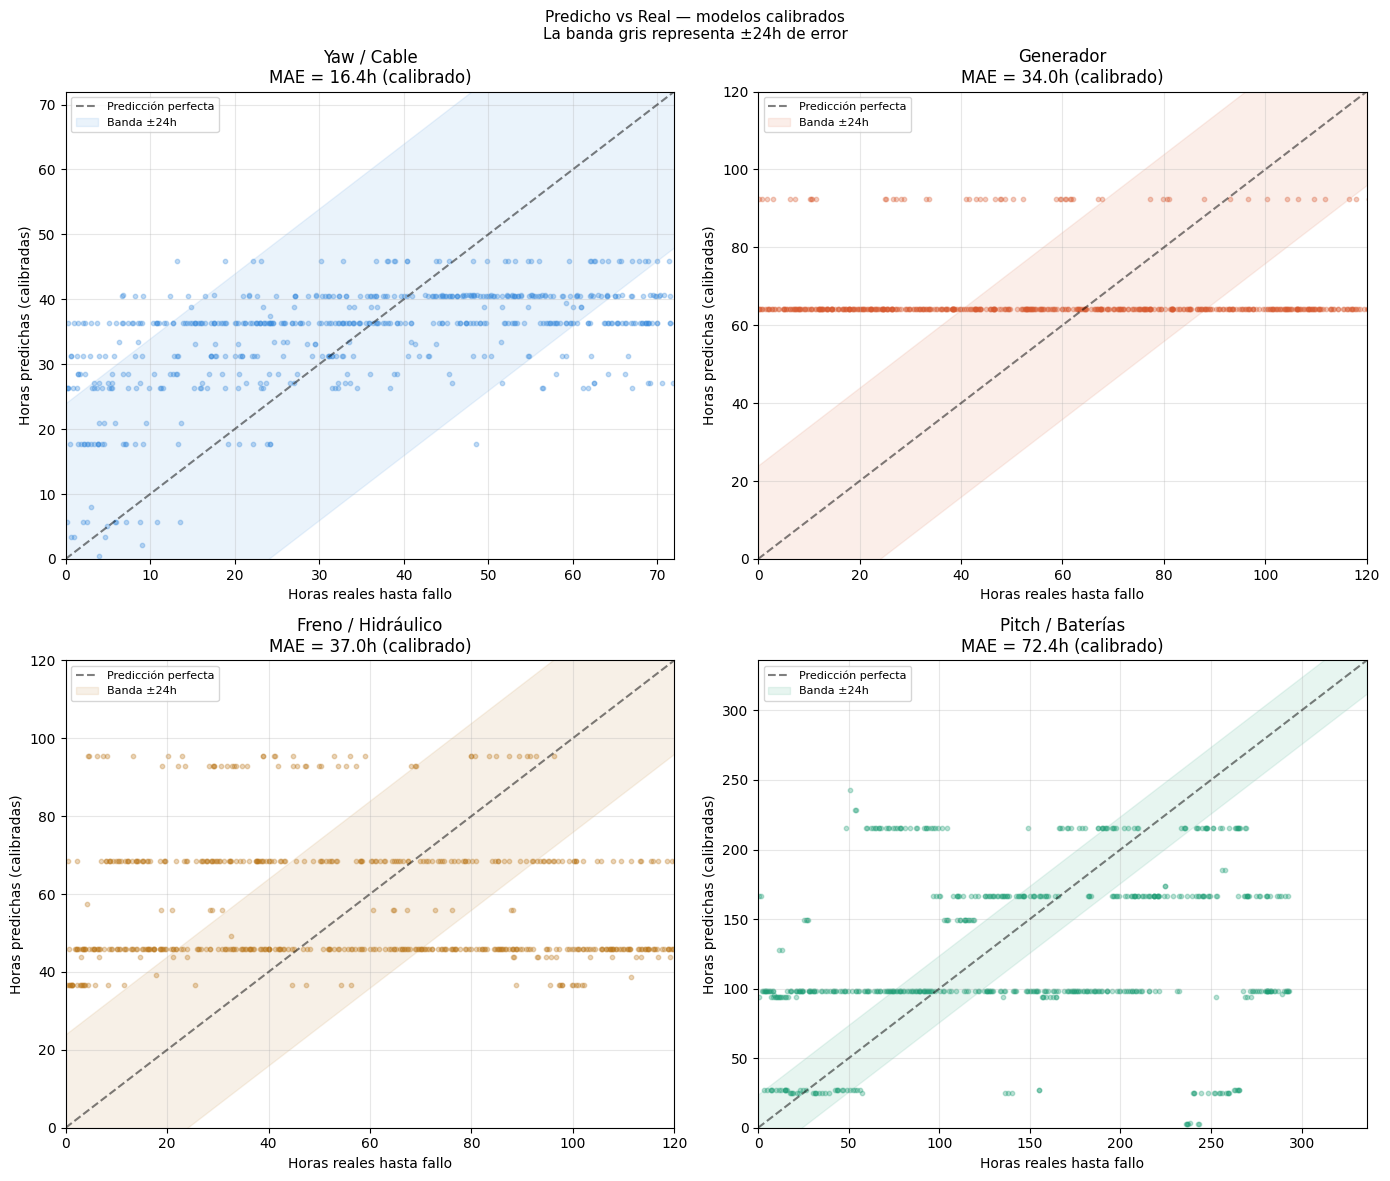

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (family, d) in enumerate(all_results.items()):
    ax  = axes[idx]
    cfg = FAMILIES[family]
    y_true = d['y_test']
    y_pred = d['pred_test_cal']
    mae    = mean_absolute_error(y_true, y_pred)

    # Muestra de 600 puntos para no sobrecargar
    idx_s = np.random.choice(len(y_true), min(600, len(y_true)), replace=False)
    ax.scatter(y_true[idx_s], y_pred[idx_s],
               alpha=0.3, s=10, color=cfg['color'])
    ax.plot([0, cfg['lead_hours']], [0, cfg['lead_hours']],
            'k--', alpha=0.5, label='Predicción perfecta')
    # Banda de ±24h
    x_line = np.linspace(0, cfg['lead_hours'], 100)
    ax.fill_between(x_line, x_line-24, x_line+24,
                    alpha=0.1, color=cfg['color'], label='Banda ±24h')
    ax.set_xlim(0, cfg['lead_hours'])
    ax.set_ylim(0, cfg['lead_hours'])
    ax.set_xlabel('Horas reales hasta fallo')
    ax.set_ylabel('Horas predichas (calibradas)')
    ax.set_title(f'{cfg["label"]}\nMAE = {mae:.1f}h (calibrado)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Predicho vs Real — modelos calibrados\n'
             'La banda gris representa ±24h de error', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'calibration_pred_vs_actual.png'),
            dpi=150, bbox_inches='tight')
plt.show()


---

## 6. Exportar Dashboard Data

In [6]:
print('Exportando datos para el dashboard...')

dashboard = {'families': {}, 'generated_at': pd.Timestamp.now().isoformat()}

for family, d in all_results.items():
    cfg          = FAMILIES[family]
    test         = d['test'].copy().reset_index(drop=True)
    pred_all_cal = d['pred_all_cal']
    results      = d['results']

    # Alert score: 1 = fallo inminente, 0 = sin urgencia
    alert_score = np.round(1.0 - (pred_all_cal / cfg['lead_hours']), 3)

    # Timeline resampleado a 6h
    tl = pd.DataFrame({
        'ts':          test['timestamp'].astype(str),
        'alert_score': alert_score,
        'pred_h':      np.round(pred_all_cal, 1),
        'is_pre':      test[f'is_pre_{family}'].astype(int),
    })
    tl['ts_dt'] = pd.to_datetime(tl['ts'])
    tl = tl.set_index('ts_dt').resample('6h').agg({
        'ts': 'first', 'alert_score': 'mean',
        'pred_h': 'mean', 'is_pre': 'max',
    }).reset_index(drop=True)
    tl['alert_score'] = tl['alert_score'].round(3)
    tl['pred_h']      = tl['pred_h'].round(1)

    # Scatter (positivos, máx 800 puntos)
    pos_mask  = test[f'is_pre_{family}'].values.astype(bool)
    y_true_h  = test.loc[pos_mask, f'hours_to_{family}'].values
    y_pred_pos = pred_all_cal[pos_mask]
    idx_s = np.random.choice(len(y_true_h), min(800,len(y_true_h)), replace=False)
    scatter = [{'x': round(float(y_true_h[i]),1), 'y': round(float(y_pred_pos[i]),1)}
               for i in sorted(idx_s)]

    dashboard['families'][family] = {
        'label':      cfg['label'],
        'color':      cfg['color'],
        'lead_hours': cfg['lead_hours'],
        'alert_h':    cfg['alert_h'],
        'metrics':    {
            'mae_raw_h':        results['mae_raw_h'],
            'mae_cal_h':        results['mae_cal_h'],
            'rmse_cal_h':       results['rmse_cal_h'],
            'r2_cal':           results['r2_cal'],
            'precision':        results['precision'],
            'recall':           results['recall'],
            'event_recall':     results['event_recall'],
            'events_detected':  results['events_detected'],
            'events_total':     results['events_total'],
        },
        'timeline':   tl[['ts','alert_score','pred_h','is_pre']].to_dict('records'),
        'events':     results['events'],
        'scatter':    scatter,
        'test_start': str(test['timestamp'].min().date()),
        'test_end':   str(test['timestamp'].max().date()),
    }
    n = len(tl)
    print(f'  {family}: {n} puntos timeline, {len(results["events"])} eventos')

out_path = os.path.join(html_dir, 'dashboard_data.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(dashboard, f, ensure_ascii=False, default=str)

size_kb = os.path.getsize(out_path)/1024
print(f'\n✅ dashboard_data.json  ({size_kb:.0f} KB)')
print(f'   Ruta: {out_path}')


Exportando datos para el dashboard...
  yaw_cable: 1461 puntos timeline, 27 eventos
  generator: 1461 puntos timeline, 10 eventos
  brake_hydro: 1461 puntos timeline, 11 eventos
  pitch_bat: 1461 puntos timeline, 3 eventos

✅ dashboard_data.json  (549 KB)
   Ruta: /home/aitor/Documentos/ai-driven-cross-generator-transfer-learning/html/dashboard_data.json


---

## 📋 Conclusiones

Los modelos calibrados corrigen el sesgo de compresión del regresor base.
El archivo `dashboard_data.json` contiene todos los datos necesarios para
el dashboard interactivo:

- Métricas por familia (antes y después de calibrar)
- Timeline de alertas resampleado a 6h
- Eventos reales con estado detectado/perdido
- Scatter predicho vs real para visualización

**Siguiente paso:** abrir `dashboard.html` en el navegador.